# Fulton Fish Market

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('/Users/mrlee/development/MSIS501/Data-Mining-And-Analytics/data/fulton.csv')
df.head()

,Mon,Tue,Wed,Thu,Date,Stormy,p,q
0,1,0,0,0,1,1,1.569217,8.994421
1,0,1,0,0,2,1,2.000000,7.707063
2,0,0,1,0,3,0,2.072321,8.350194
3,0,0,0,1,4,1,2.247139,8.656955
4,0,0,0,0,5,1,2.664327,7.844241


## 1) EDA

### 1.a) Scatterplots

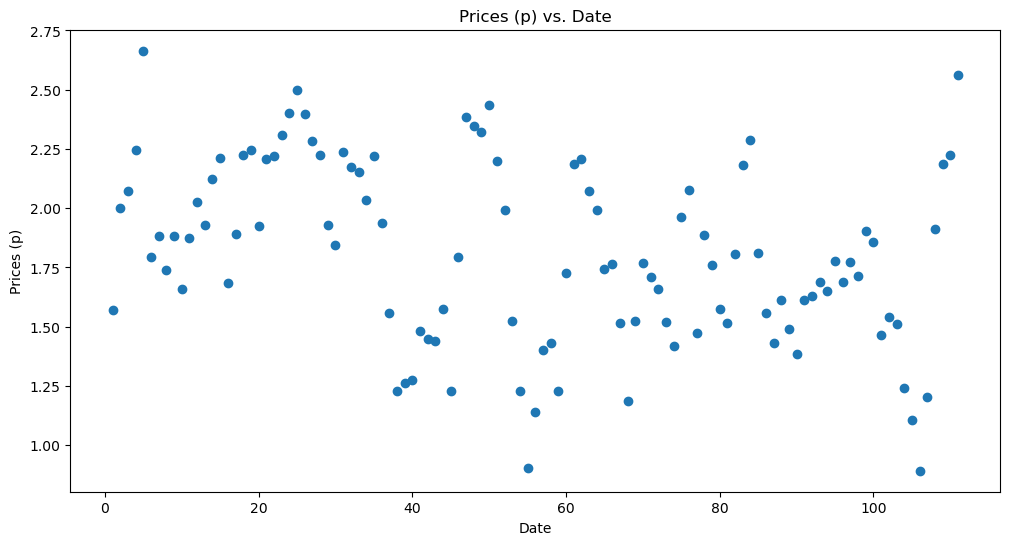

In [65]:
# P on y axis, q on date axis
plt.figure(figsize=(12, 6))
plt.scatter(df['Date'], df['p'])
plt.title("Prices (p) vs. Date")
plt.xlabel("Date")
plt.ylabel("Prices (p)")
plt.show()

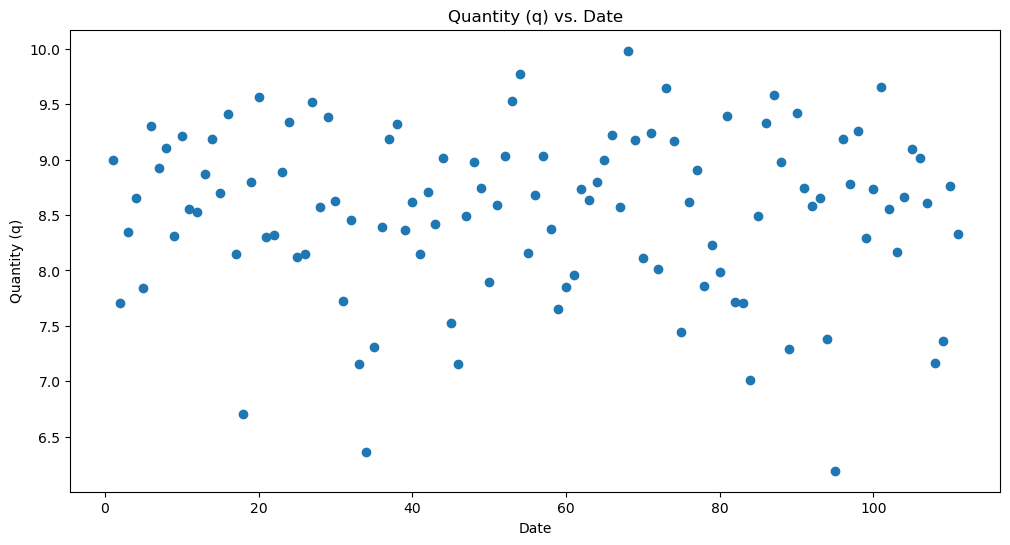

In [66]:
# q on y axis, p on date axis
plt.figure(figsize=(12, 6))
plt.scatter(df['Date'], df['q'])
plt.title("Quantity (q) vs. Date")
plt.xlabel("Date")
plt.ylabel("Quantity (q)")
plt.show()

Prices show more variation than quantity. There are some dates where prices are stable but show more significant fluctuations. Quantities are more stable than prices. 

### 1.b) Average price and quantity

In [67]:
# Average price (p) and quantity (q) of fish sold on each weekday (Mon-Thu)
weekday_avg = df[['Mon', 'Tue', 'Wed', 'Thu', 'p', 'q']].copy()
weekday_avg['day_of_week'] = weekday_avg[['Mon', 'Tue', 'Wed', 'Thu']].idxmax(axis=1)
weekday_avg = weekday_avg.groupby('day_of_week').mean()
weekday_avg = weekday_avg[['p', 'q']]
weekday_avg


,p,q
day_of_week,,
Mon,1.784620,8.734888
Thu,1.868307,8.762598
Tue,1.792573,8.207339
Wed,1.798947,8.164622


Thursday is when fish are sold for the highest price. One reason for this is due to demand being the most on that day. 

## 2) Linear Regression

### 2.a) Linear Regression Equation

In [68]:
import statsmodels.formula.api as smf

# Build a linear regression model to predict quantity (q), using all of the other variables (except the “Stormy” and “Date” variable).
linear_regression_model_1 = smf.ols('q ~ Mon + Tue + Wed + Thu + p', data=df)
linear_regression_model_1_results = linear_regression_model_1.fit()
print(linear_regression_model_1_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      q   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     5.940
Date:                Fri, 06 Dec 2024   Prob (F-statistic):           7.08e-05
Time:                        20:30:39   Log-Likelihood:                -110.00
No. Observations:                 111   AIC:                             232.0
Df Residuals:                     105   BIC:                             248.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.7320      0.336     28.936      0.0

Linear Regression Equation:

q = 9.7320 + 0.0143(Mon) + -0.5162(Tue) + -0.5554(Wed) + 0.0816(Thu) + -0.5625(p)

### 2.b) Model Evaluation

R^2 = 0.220

Significant Values:
- Mon
- Thu

### 2.c) Coefficients

Coefficient of price (p): -0.5625

The coefficient can provide useful understanding for the relationship between price and quantity, however we have to keep in mind that the variable p is not as significant compared to Mon and Thu. 

## 3) Causal Effect of p on q

### 3.a) Two-day lagged weather

'Stormy', weather, could be a good instrument as it satisfies the two properties: relevance and exogenous. 
It is relevant because the weather that happened 2 days ago can affect the supply, which affects price. 
It is exogenous because past weather does not have a direct affect on quantity fish sold. 

### 3.b) Instrument could correlate directly with quantity of fish sold?

The instrument could correlate directly with quantity of fish sold if the weather two days ago influence buyer behavior as it violates the exogenous condition. Another condition is when the storm reduces fish supply significantly in a case where it will impact the quantity sold. 

### 3.c) iv regression

In [69]:
!pip install linearmodels==6.1

In [70]:
# IV Regression
from linearmodels.iv import IV2SLS

formula = 'q ~ 1 + [p ~ Stormy] + Mon + Tue + Wed + Thu'

iv_regression = IV2SLS.from_formula(formula=formula, data=df)
iv_regression_results = iv_regression.fit()

print(iv_regression_results.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                      q   R-squared:                      0.1391
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0981
No. Observations:                 111   F-statistic:                    24.946
Date:                Fri, Dec 06 2024   P-value (F-stat)                0.0001
Time:                        20:30:41   Distribution:                  chi2(5)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      10.745     0.7860     13.671     0.0000      9.2043      12.285
Mon           -0.0254     0.2154    -0.1179     0.90

### 3.d) Direction of Coefficient of price

Coefficient of price change from -0.5625 (OLS) to -1.6788 (IV-2SLS). Coefficient in the IV Regression is more negative. This is expected higher prices can lead to reduction of quantity sold. IV regression has stronger causal impact on quantity and it provides more accurate relation between price-quantity through endogeneity. 

### 3.e) Updated Linear Regression Equation 

Updated Linear Regression Equation:

q = 10.745 + -0.0254(Mon) + -0.5308(Tue) + -0.5664(Wed) + 0.1093(Thu) + -1.1194(p)

## 4) Calculating Optimal Fish Price

### 4.a) Calculate Quantity

In [71]:
# Values
Mon, Tue, Wed, Thu = 1, 0, 0, 0
p = 0.1

# Calculate the quantity using linear regression from question 3e
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)
print("Quantity: ", q)

print("Revenue: ", p * q)

Quantity:  10.60766
Revenue:  1.0607659999999999


### 4.b) List of prices

In [72]:
import numpy as np
p = np.arange(0, 6, 0.01)
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)

revenue_list = p * q
revenue_list.size


600

### 4.c) Plot prices and revenues 

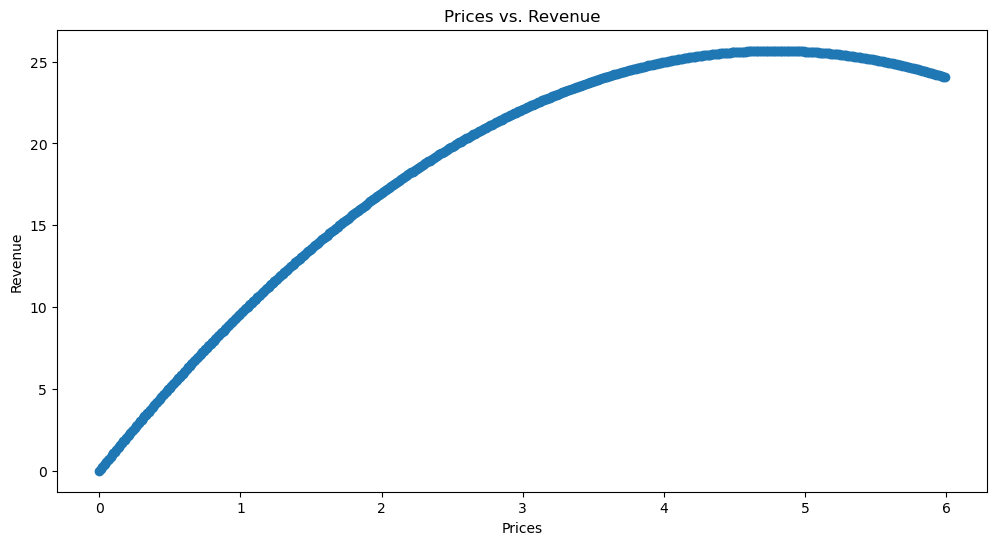

In [73]:
# Create scatterplot of prices vs. revenue
plt.figure(figsize=(12, 6))
plt.scatter(p, revenue_list)
plt.title("Prices vs. Revenue")
plt.xlabel("Prices")
plt.ylabel("Revenue")
plt.show()

In [74]:
# Get the price that maximizes revenue
max_revenue = revenue_list.max()
max_revenue_index = revenue_list.argmax()
optimal_price = p[max_revenue_index]
print("Optimal price: ", optimal_price)

Optimal price:  4.79


Sellers should set $4.79 for price on Monday. 

### 4.d) Repeat for Tue, Wed, Thu

Tue

In [75]:
Mon, Tue, Wed, Thu = 0, 1, 0, 0
p = 0.1

# Calculate the quantity using linear regression from question 3e
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)
print("Quantity: ", q)

print("Revenue: ", p * q)

Quantity:  10.10226
Revenue:  1.010226


In [76]:
p = np.arange(0, 6.01, 0.01)
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)

revenue_list = p * q
revenue_list.size

601

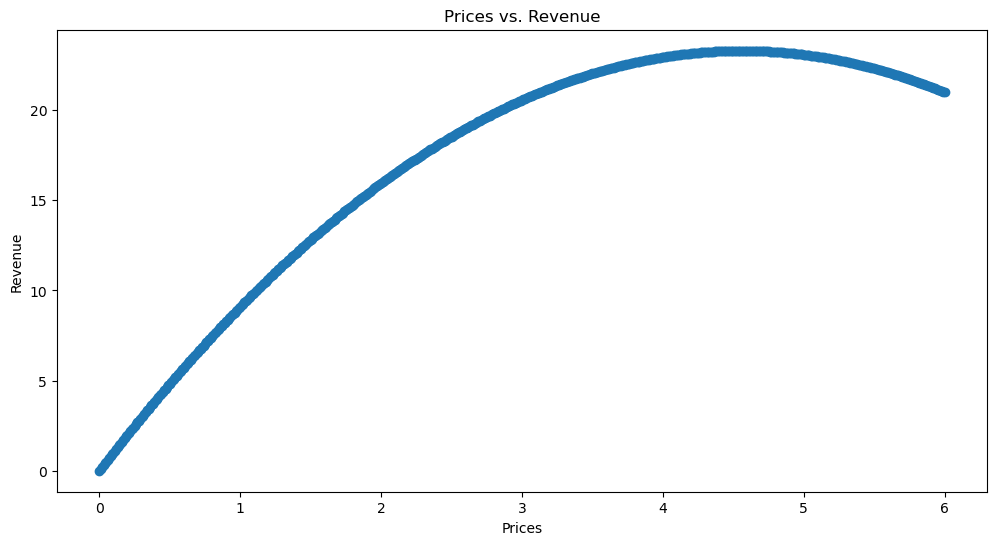

In [77]:
# Create scatterplot of prices vs. revenue
plt.figure(figsize=(12, 6))
plt.scatter(p, revenue_list)
plt.title("Prices vs. Revenue")
plt.xlabel("Prices")
plt.ylabel("Revenue")
plt.show()

In [78]:
# Get the price that maximizes revenue
max_revenue = revenue_list.max()
max_revenue_index = revenue_list.argmax()
optimal_price = p[max_revenue_index]
print("Optimal price: ", optimal_price)

Optimal price:  4.5600000000000005


Wed

In [79]:
Mon, Tue, Wed, Thu = 0, 0, 1, 0
p = 0.1

# Calculate the quantity using linear regression from question 3e
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)
print("Quantity: ", q)

print("Revenue: ", p * q)

Quantity:  10.066659999999999
Revenue:  1.0066659999999998


In [80]:
p = np.arange(0, 6.01, 0.01)
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)

revenue_list = p * q
revenue_list.size

601

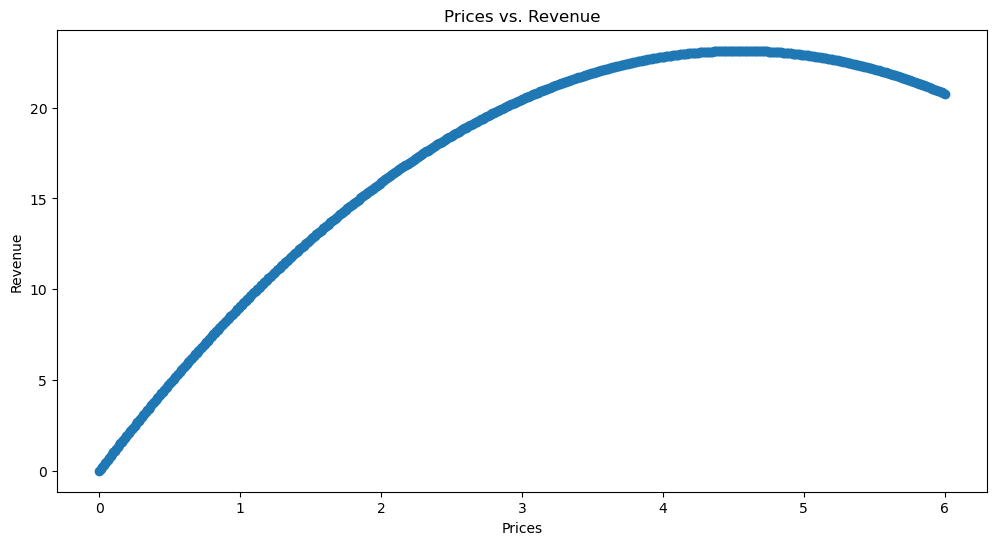

In [81]:
# Create scatterplot of prices vs. revenue
plt.figure(figsize=(12, 6))
plt.scatter(p, revenue_list)
plt.title("Prices vs. Revenue")
plt.xlabel("Prices")
plt.ylabel("Revenue")
plt.show()

In [82]:
# Get the price that maximizes revenue
max_revenue = revenue_list.max()
max_revenue_index = revenue_list.argmax()
optimal_price = p[max_revenue_index]
print("Optimal price: ", optimal_price)

Optimal price:  4.55


Thu

In [83]:
Mon, Tue, Wed, Thu = 0, 0, 0, 1
p = 0.1

# Calculate the quantity using linear regression from question 3e
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)
print("Quantity: ", q)

print("Revenue: ", p * q)

Quantity:  10.742359999999998
Revenue:  1.0742359999999997


In [84]:
p = np.arange(0, 6.01, 0.01)
q = 10.745 + -0.0254 * (Mon) + -0.5308 * (Tue) + -0.5664 * (Wed) + 0.1093 * (Thu) + -1.1194 * (p)

revenue_list = p * q
revenue_list.size

601

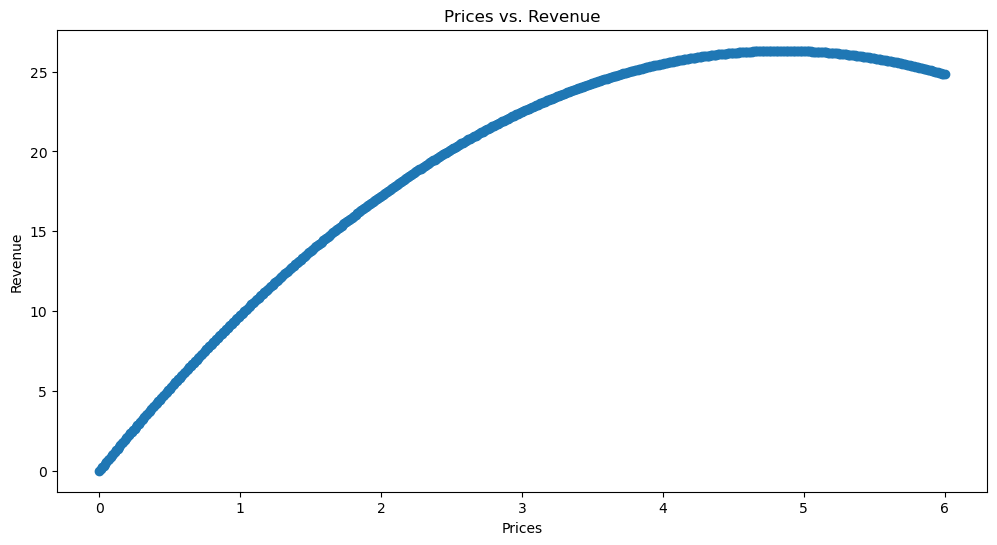

In [85]:
# Create scatterplot of prices vs. revenue
plt.figure(figsize=(12, 6))
plt.scatter(p, revenue_list)
plt.title("Prices vs. Revenue")
plt.xlabel("Prices")
plt.ylabel("Revenue")
plt.show()

In [86]:
# Get the price that maximizes revenue
max_revenue = revenue_list.max()
max_revenue_index = revenue_list.argmax()
optimal_price = p[max_revenue_index]
print("Optimal price: ", optimal_price)

Optimal price:  4.8500000000000005
